In [3]:
# read sub data

import pandas as pd
import seaborn as sns
import os

data_dir = "/home/alily/Documents/GitHub/TongueTwister/Experiments/TT1/data/alldat"
sub_list = ['sub-02','sub-03','sub-04','sub-05','sub-06']

data = []
for sub in sub_list:
    d=(pd.read_csv(f"{data_dir}/{sub}_alldat.tsv",sep="\t"))
    data.append(d)
data = pd.concat(data, ignore_index=True)
data = data.dropna()


In [4]:
# calculate syllable time (ST)
data["ST"] = data["offset_sec"]-data["onset_sec"]

#average aross syllables

data["avg_ST"] = data.groupby("syllable")["ST"].transform("mean")


In [5]:
import numpy as np

# calculate mean ST per subject
sub_medians = []

for sub in sub_list:
    sub_data = data[data["subject"]==sub]


print(f"group: mean syllable time = {np.mean(sub_medians)}")

group: mean syllable time = nan


/home/alily/Documents/GitHub/TongueTwister/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/alily/Documents/GitHub/TongueTwister/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


sub-02: mean syllable time = 0.20000000000000018


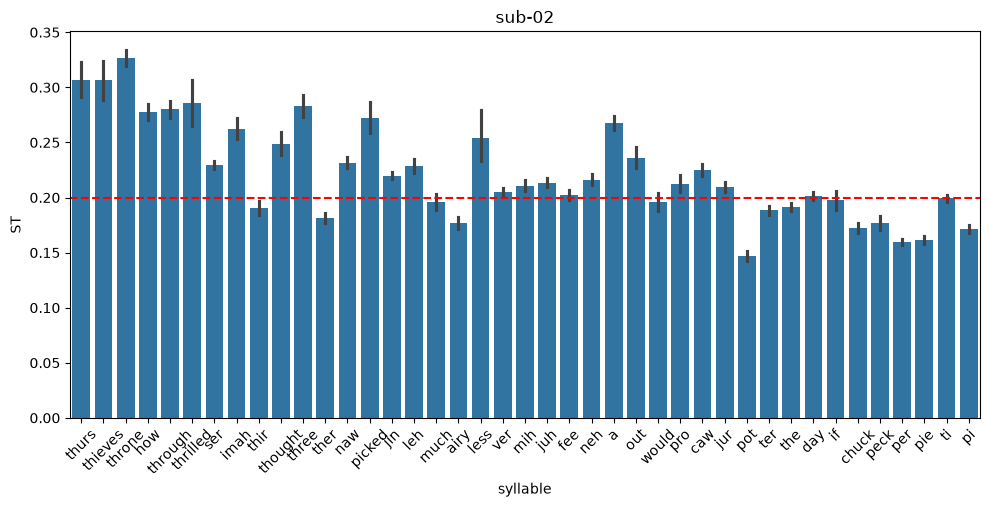

sub-03: mean syllable time = 0.19999999999999996


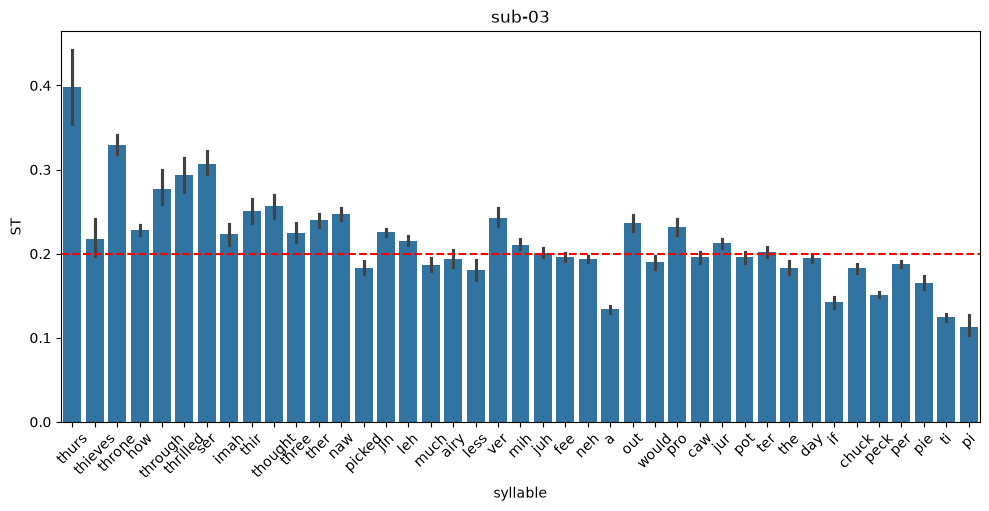

sub-04: mean syllable time = 0.2200000000000002


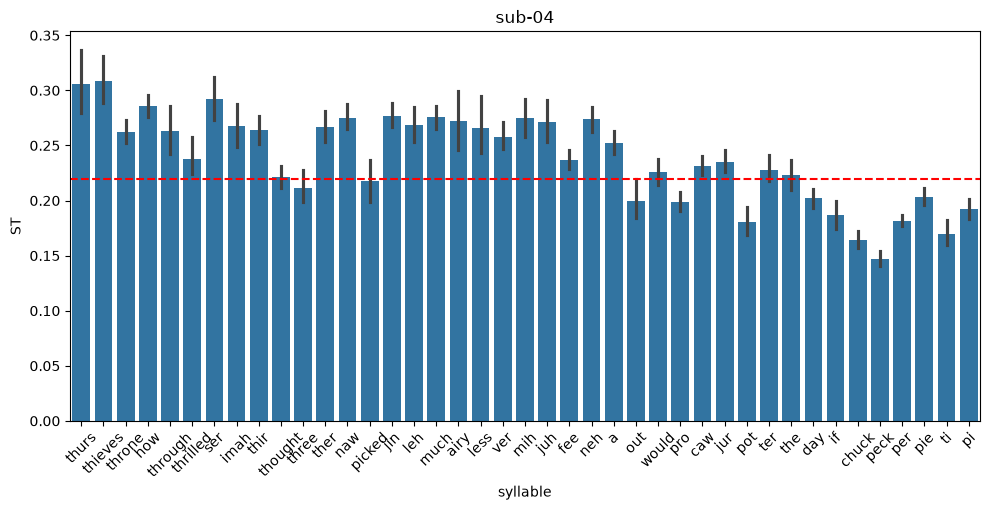

sub-05: mean syllable time = 0.16000000000000014


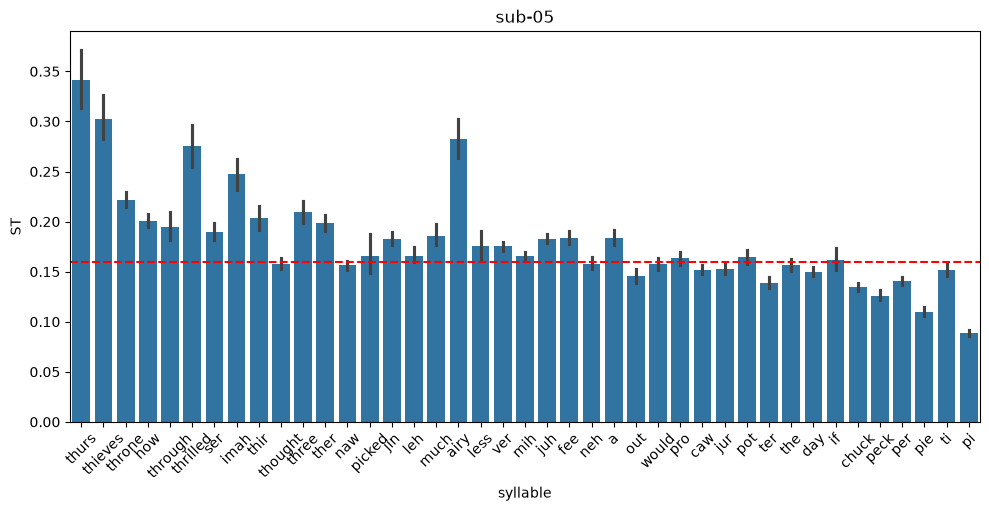

sub-06: mean syllable time = 0.24


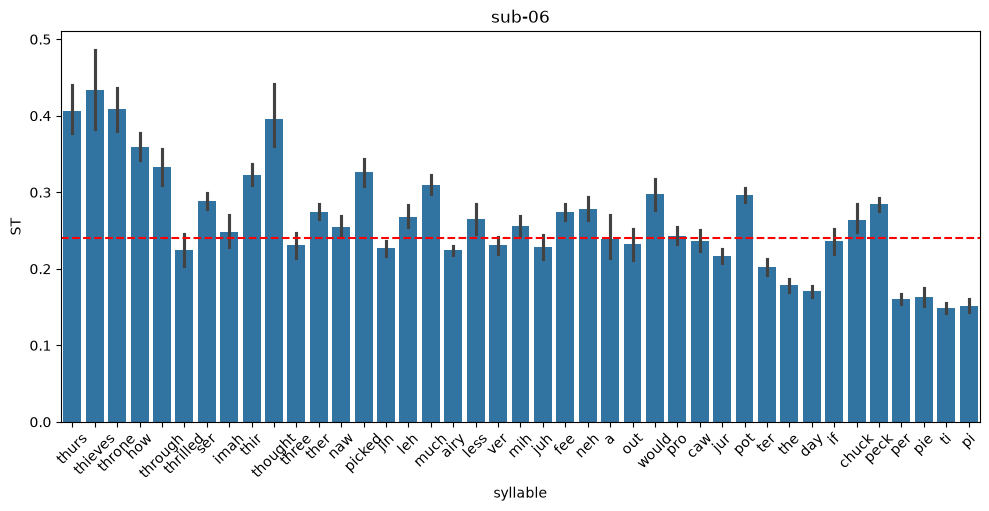

In [15]:
# plot ST per subject

import matplotlib.pyplot as plt
order = (data.groupby("syllable")["ST"].mean().sort_values(ascending=False).index)

for sub in sub_list:

    # filter subjects data
    sub_data = data[data["subject"]==sub]

    # calculate median
    sub_median = sub_data["ST"].median()
    sub_medians.append(sub_median)
    print(f"{sub}: mean syllable time = {sub_median}")

    # calculate means
    sub_avg = sub_data.groupby("syllable")["ST"].mean()

    # plot
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=sub_data, x="syllable", y="ST",order=order)

    #max_idx = sub_avg.values.argmax()
    #ax.patches[max_idx].set_color("red")

    plt.axhline(y=sub_median, color="red", linestyle="--")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.title(f"{sub}")
    plt.show()

/tmp/ipykernel_418820/2240065677.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(data=data, x="syllable", y="ST", hue="subject", marker="o", style="subject", markers=True, dashes=False,  ci=None)


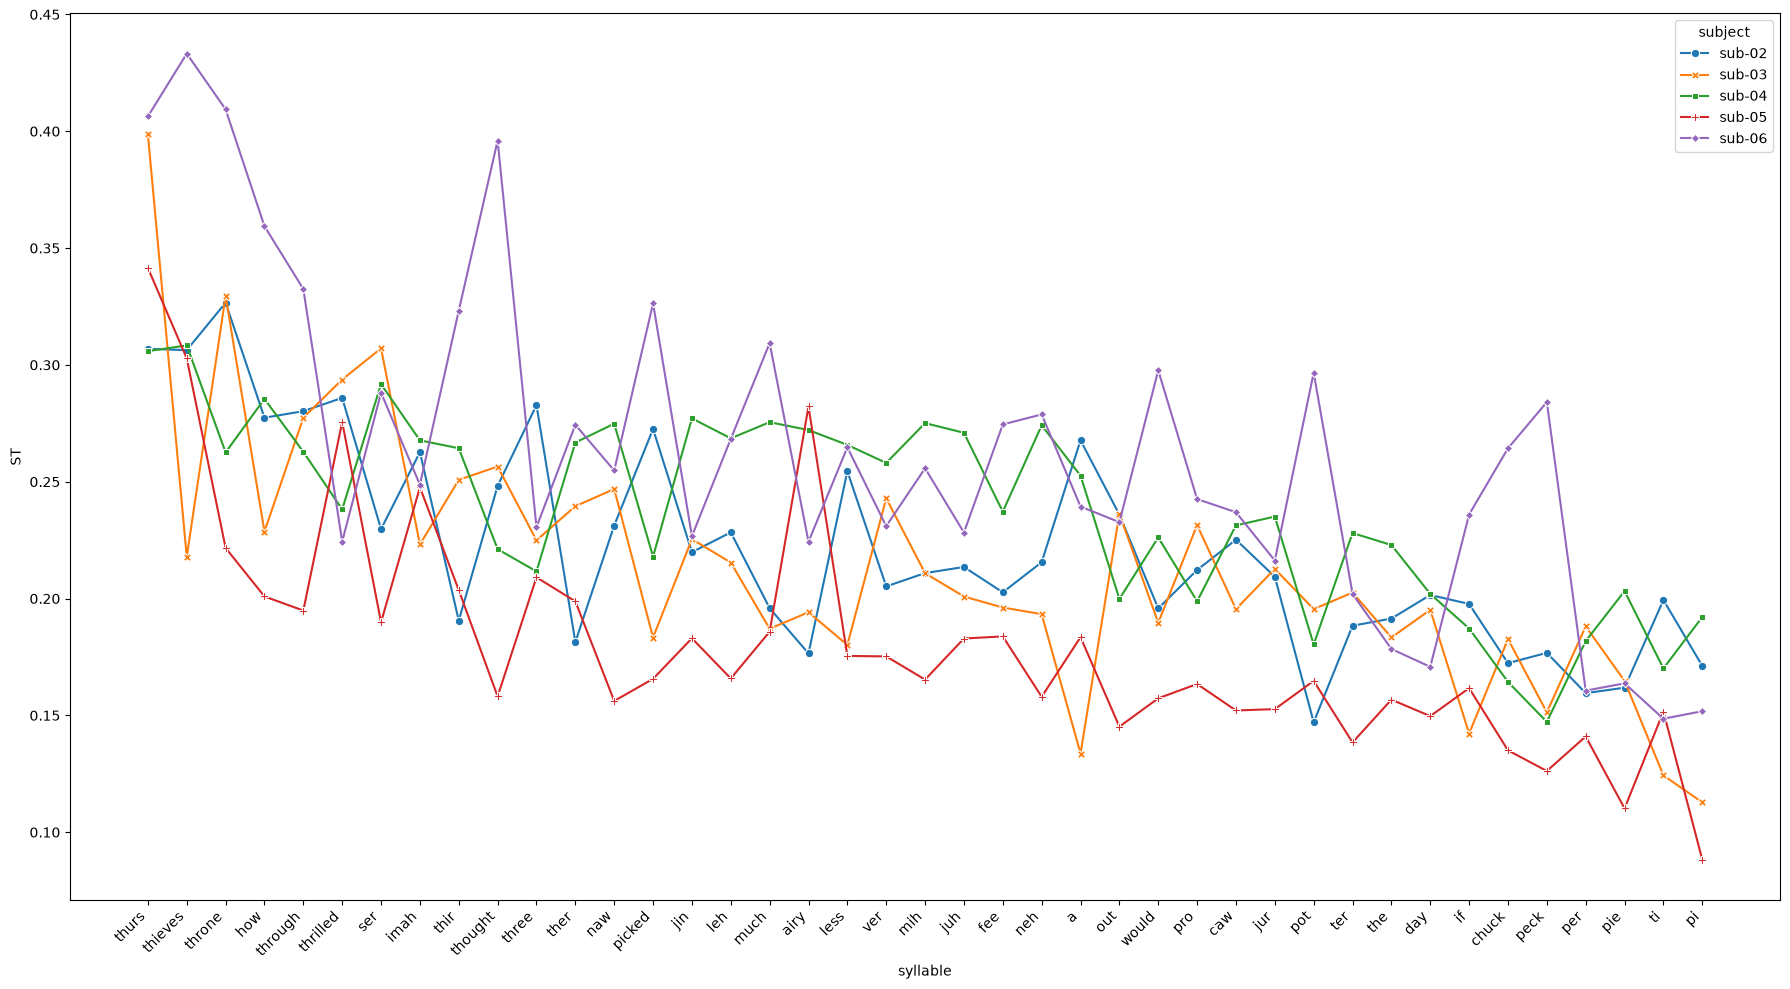

In [27]:
order = (data.groupby("syllable")["ST"].mean().sort_values(ascending=False).index)
data["syllable"] = pd.Categorical(data["syllable"], categories=order, ordered=True)

plt.figure(figsize=(18,10))
ax = sns.lineplot(data=data, x="syllable", y="ST", hue="subject", marker="o", style="subject", markers=True, dashes=False,  ci=None)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

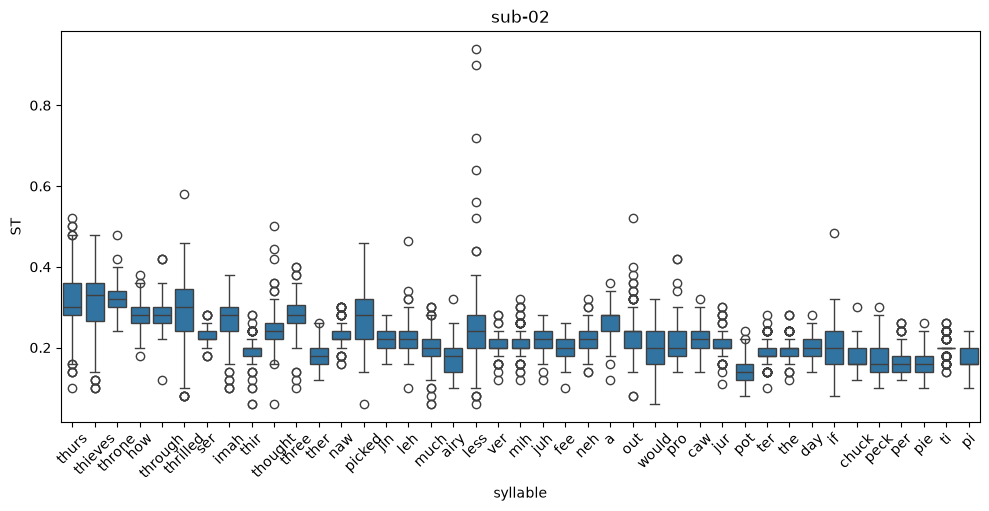

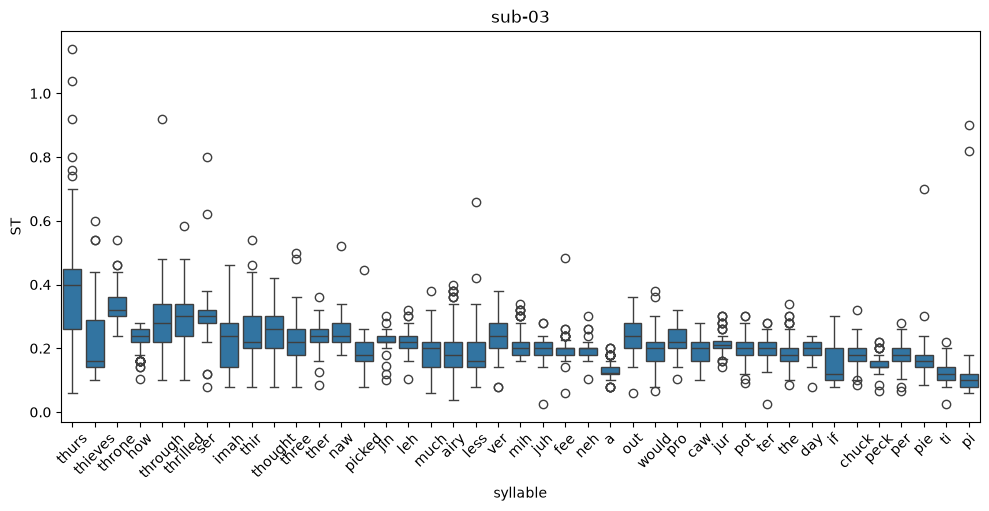

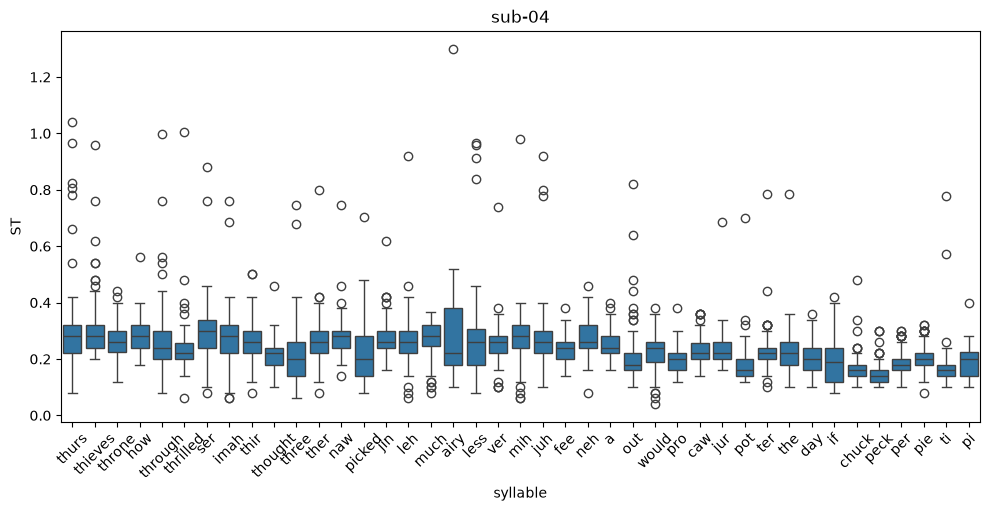

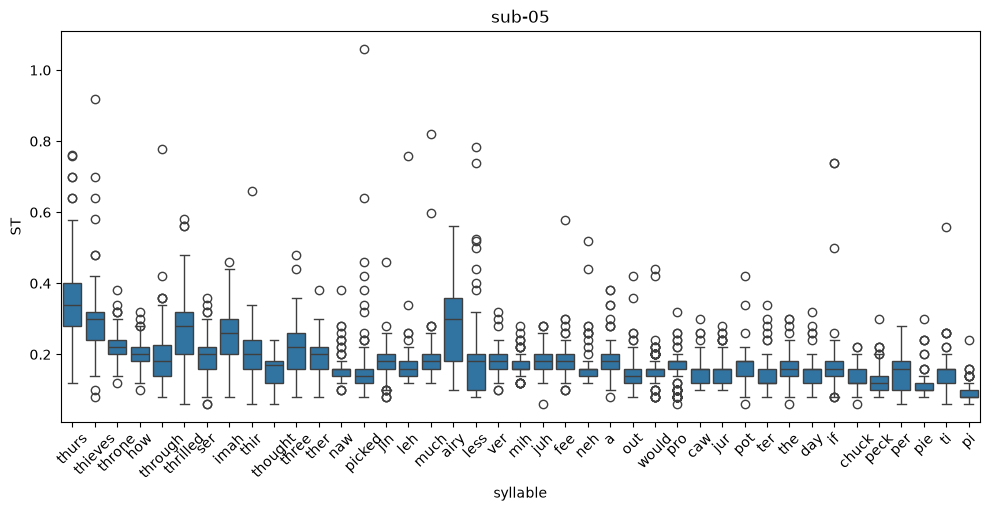

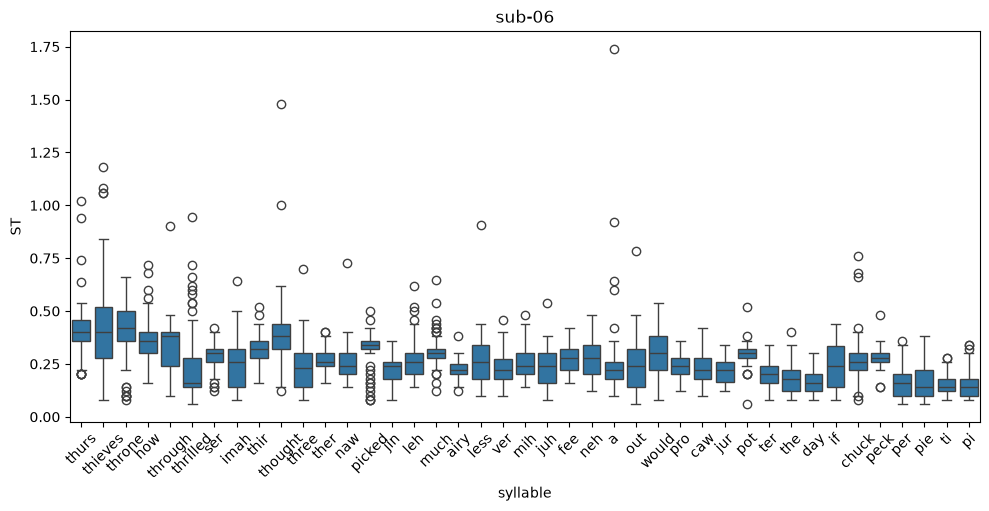

In [11]:
for sub in sub_list:

    # filter subjects data
    sub_data = data[data["subject"]==sub]

    # calculate median
    #sub_median = sub_data["ST_normalized"].median()
    #sub_medians.append(sub_median)
    #print(f"{sub}: mean syllable time = {sub_median}")

    # calculate and order means
    #order = (sub_data.groupby("syllable")["ST_normalized"].mean().sort_values(ascending=False).index)

    # plot
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=sub_data, x="syllable", y="ST",order=order)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.title(f"{sub}")
    plt.show()

In [33]:
outliers = data[data["ST"]>0.55]
outliers.head(21)

,subject,run,trial,syllable,wav_file,syllable_number,onset_sec,offset_sec,ST
584,sub-02,1,39,less,behav_sub-02_run-01_trial-39.wav,13,3.8525,4.7525,0.9000
2167,sub-02,4,6,less,behav_sub-02_run-04_trial-06.wav,17,4.0525,4.6125,0.5600
3467,sub-02,5,39,less,behav_sub-02_run-05_trial-39.wav,14,3.4725,4.4125,0.9400
3544,sub-02,6,2,less,behav_sub-02_run-06_trial-02.wav,8,2.4525,3.1725,0.7200
3548,sub-02,6,2,less,behav_sub-02_run-06_trial-02.wav,12,3.8925,4.5325,0.6400
5324,sub-02,8,17,thrilled,behav_sub-02_run-08_trial-17.wav,8,4.1125,4.6925,0.5800
29,sub-03,1,2,thurs,behav_sub-03_run-01_trial-02.wav,8,3.2525,3.8325,0.5800
1001,sub-03,2,21,thurs,behav_sub-03_run-02_trial-21.wav,9,3.9925,4.7525,0.7600
1164,sub-03,2,31,ser,behav_sub-03_run-02_trial-31.wav,12,4.1925,4.8125,0.6200
1165,sub-03,2,32,through,behav_sub-03_run-02_trial-32.wav,1,0.0725,0.9925,0.9200


In [41]:
downlowers = data[data["ST"] < 0.05]
downlowers.head(60)

,subject,run,trial,syllable,wav_file,syllable_number,onset_sec,offset_sec,ST
928,sub-01,1,47,thought,behav_sub-01_run-01_trial-47.wav,22,4.4725,4.5000,0.0275
1964,sub-01,2,31,ser,behav_sub-01_run-02_trial-31.wav,20,4.4525,4.5000,0.0475
3223,sub-01,3,25,ter,behav_sub-01_run-03_trial-25.wav,24,4.4725,4.5000,0.0275
3622,sub-01,3,44,day,behav_sub-01_run-03_trial-44.wav,22,4.4725,4.5000,0.0275
3745,sub-01,3,50,day,behav_sub-01_run-03_trial-50.wav,21,4.4725,4.5000,0.0275
5366,sub-01,4,63,fee,behav_sub-01_run-04_trial-63.wav,23,4.4725,4.5000,0.0275
5583,sub-01,5,9,ter,behav_sub-01_run-05_trial-09.wav,25,4.4725,4.5000,0.0275
5915,sub-01,5,24,per,behav_sub-01_run-05_trial-24.wav,24,4.4725,4.5000,0.0275
6574,sub-01,5,55,day,behav_sub-01_run-05_trial-55.wav,22,4.4725,4.5000,0.0275
7592,sub-01,6,41,fee,behav_sub-01_run-06_trial-41.wav,22,4.4725,4.5000,0.0275
